In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
x = tf.random.normal((300000, 25))
y = tf.random.uniform((300000, 1))                  # regression based dataset

I0000 00:00:1790129209.955559      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790129209.961148      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
x = np.array(x).astype('float32') / 255.0
y = np.array(y).astype('float32')

In [4]:
from sklearn.model_selection import train_test_split as ttt

x_train, x_test, y_train, y_test = ttt(x,y, test_size=0.3, random_state=42)

print(x_train.shape)
print(x_test.shape)

(210000, 25)
(90000, 25)


### Optuna Model - Setting Layers Manually

In [5]:
import optuna

In [6]:
# STEP 1
def my_model(trial):
    # STEP 1.1
    dropouts = trial.suggest_float('dropout', 0.1, 0.4, step=0.05)

    layer_1 = trial.suggest_int('layer_1', 32, 128, step=16)
    layer_2 = trial.suggest_int('layer_2', 64, 256, step=32)
    layer_3 = trial.suggest_int('layer_3', 64, 256, step=16)
    layer_4 = trial.suggest_int('layer_4', 32, 128, step=16)
    layer_5 = trial.suggest_int('layer_5', 10, 15, step=5)

    activation_fn = trial.suggest_categorical('activation_fn', ['relu', 'leaky_relu', 'elu', 'tanh'])
    initializer = trial.suggest_categorical('initializer', ['glorot_normal', 'glorot_uniform', 'he_normal', 'he_uniform'])
    
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    SGD_momentum = trial.suggest_float('SGD_momentum', 0.3, 0.75)
    

    # STEP 1.2
    model = keras.Sequential([
        keras.Input(shape=(25,)),
        layers.Dense(layer_1, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_2, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_3, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_4, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),
        layers.Dense(layer_5, activation=activation_fn, kernel_initializer=initializer),
        layers.Dropout(dropouts),

        layers.Dense(1)
    ])


    # STEP 1.3
    model.compile(
        loss = keras.losses.MeanSquaredError(),
        optimizer = keras.optimizers.SGD(lr, momentum=SGD_momentum),
        metrics = ['mae']
    )

    # STEP 1.4
    early_stop = EarlyStopping(
        monitor = 'val_loss',
        patience = 3,
        restore_best_weights = True,
        verbose = 1
    ) 


    # STEP 1.5
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        epochs = 5,
        validation_split = 0.2,
        verbose = 0
    )

    # STEP 1.6
    #  SAVING HISTORY DIRECTLY TO OPTUNA:
    trial.set_user_attr('train_loss', history.history['loss'])
    trial.set_user_attr('val_loss', history.history['val_loss'])
    trial.set_user_attr('train_mae', history.history['mae'])
    trial.set_user_attr('val_mae', history.history['val_mae'])
    
    best_val_loss = min(history.history['val_loss'])
    return best_val_loss


# STEP 2
study = optuna.create_study(direction='minimize')
study.optimize(my_model, n_trials = 3)

[I 2026-09-23 02:06:50,645] A new study created in memory with name: no-name-5b3f7a1c-d8f3-4a38-9d85-3d65bfe3bedb
I0000 00:00:1790129216.470756     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Restoring model weights from the end of the best epoch: 5.


[I 2026-09-23 02:08:07,856] Trial 0 finished with value: 0.08370792865753174 and parameters: {'dropout': 0.2, 'layer_1': 80, 'layer_2': 128, 'layer_3': 160, 'layer_4': 96, 'layer_5': 15, 'activation_fn': 'tanh', 'initializer': 'glorot_normal', 'lr': 0.0005352189869949894, 'SGD_momentum': 0.5157207320645643}. Best is trial 0 with value: 0.08370792865753174.


Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


[I 2026-09-23 02:09:09,274] Trial 1 finished with value: 0.08367368578910828 and parameters: {'dropout': 0.15000000000000002, 'layer_1': 112, 'layer_2': 64, 'layer_3': 208, 'layer_4': 128, 'layer_5': 15, 'activation_fn': 'relu', 'initializer': 'he_uniform', 'lr': 0.0013261688320174957, 'SGD_momentum': 0.5578015599315476}. Best is trial 1 with value: 0.08367368578910828.


Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


[I 2026-09-23 02:10:23,933] Trial 2 finished with value: 0.08365744352340698 and parameters: {'dropout': 0.2, 'layer_1': 96, 'layer_2': 128, 'layer_3': 144, 'layer_4': 112, 'layer_5': 15, 'activation_fn': 'leaky_relu', 'initializer': 'glorot_normal', 'lr': 0.01834991321506851, 'SGD_momentum': 0.5846625483139949}. Best is trial 2 with value: 0.08365744352340698.


In [7]:
import matplotlib.pyplot as plt

In [8]:
print(study.best_trial)
print()
print(study.best_params)


FrozenTrial(number=2, state=<TrialState.COMPLETE: 1>, values=[0.08365744352340698], datetime_start=datetime.datetime(2026, 9, 23, 2, 9, 9, 275504), datetime_complete=datetime.datetime(2026, 9, 23, 2, 10, 23, 933120), params={'dropout': 0.2, 'layer_1': 96, 'layer_2': 128, 'layer_3': 144, 'layer_4': 112, 'layer_5': 15, 'activation_fn': 'leaky_relu', 'initializer': 'glorot_normal', 'lr': 0.01834991321506851, 'SGD_momentum': 0.5846625483139949}, user_attrs={'train_loss': [0.0835910215973854, 0.0831485390663147, 0.08316129446029663, 0.08316991478204727, 0.08314988762140274], 'val_loss': [0.08372017741203308, 0.08365744352340698, 0.0836583599448204, 0.08366408944129944, 0.08365854620933533], 'train_mae': [0.25009384751319885, 0.24955898523330688, 0.24960832297801971, 0.2496391087770462, 0.24958540499210358], 'val_mae': [0.2506599426269531, 0.25059157609939575, 0.2505929172039032, 0.25059986114501953, 0.25059252977371216]}, system_attrs={}, intermediate_values={}, distributions={'dropout': Fl

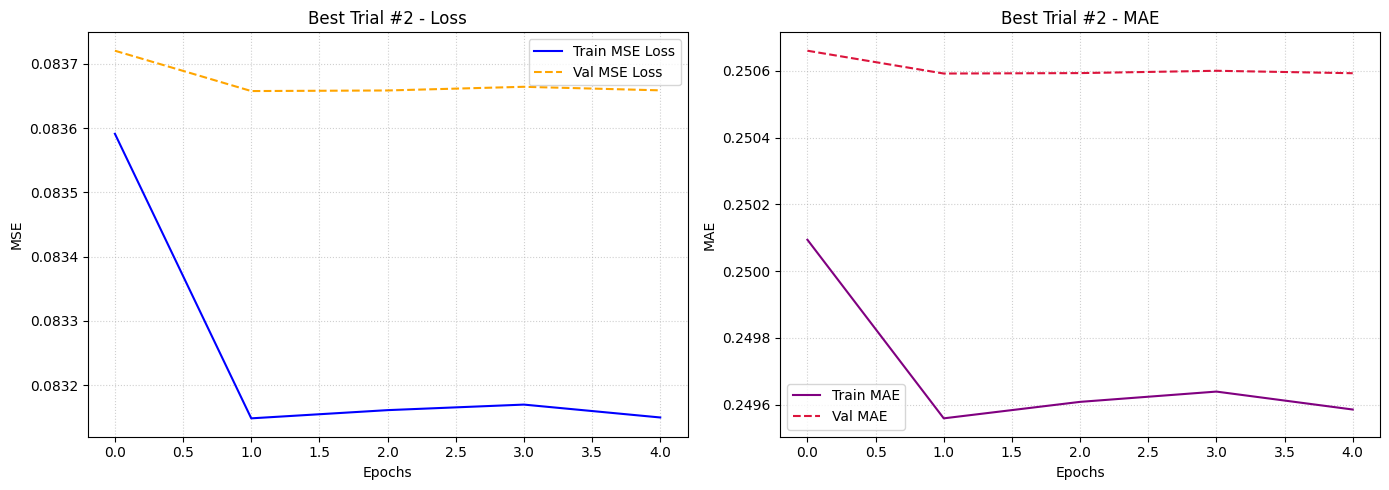

In [9]:
# 1. Grab the best trial from the study
best_trial = study.best_trial

# 2. Extract the saved history
train_loss = best_trial.user_attrs['train_loss']
val_loss   = best_trial.user_attrs['val_loss']
train_mae  = best_trial.user_attrs['train_mae']
val_mae    = best_trial.user_attrs['val_mae']

# 3. Plot with Matplotlib!
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train MSE Loss', color='blue')
plt.plot(val_loss, label='Val MSE Loss', color='orange', linestyle='--')
plt.title(f"Best Trial #{best_trial.number} - Loss")
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(train_mae, label='Train MAE', color='purple')
plt.plot(val_mae, label='Val MAE', color='crimson', linestyle='--')
plt.title(f"Best Trial #{best_trial.number} - MAE")
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Optuna Model - Setting Layers by Optuna

In [12]:
# STEP 1
def my_model(trial):

    # STEP 1.1
    n_layers = trial.suggest_int('n_layers', 2,6)

    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    SGD_momentum = trial.suggest_float('SGD_momentum', 0.3, 0.7)


    # STEP 1.2
    model = keras.Sequential()
    model.add(keras.Input(shape=(25,)))

    # STEP 1.3
    for i in range(n_layers):

        # STEP 1.3.1
        neurons = trial.suggest_int(f'neuron_{i}', 16,156, step=16)
        activation_fn = trial.suggest_categorical(f'act_{i}', ['relu', 'elu', 'tanh', 'leaky_relu'])
        initializer = trial.suggest_categorical(f'initializer_{i}', ['he_normal', 'glorot_normal'])
        dropouts = trial.suggest_float(f'dropout_{i}', 0.0, 0.4, step=0.05)

        
        # STEP 1.3.2
        model.add(layers.Dense(neurons, activation=activation_fn, kernel_initializer=initializer))

        
        # STEP 1.3.3
        if dropouts > 0.0:
            model.add(layers.Dropout(dropouts))

    
    # STEP 1.4
    model.add(layers.Dense(1))


    # STEP 1.5
    model.compile(
        loss = keras.losses.MeanSquaredError(),
        optimizer = keras.optimizers.SGD(lr, momentum=SGD_momentum),
        metrics = ['mae']
    )


    # STEP 1.6
    early_stop=EarlyStopping(
        patience = 3,
        monitor='val_loss',
        restore_best_weights = True,
        verbose = 1
    )


    # STEP 1.6
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        epochs = 5,
        batch_size = 128,
        validation_split = 0.2,
        verbose = 1
    )


    # STEP 1.7
    trial.set_user_attr('train_loss', history.history['loss'])
    trial.set_user_attr('val_loss', history.history['val_loss'])
    trial.set_user_attr('train_mae', history.history['mae'])
    trial.set_user_attr('val_mae', history.history['val_mae'])


    # STEP 1.8
    best_loss = min(history.history['val_loss'])
    return best_loss


# STEP 2
study = optuna.create_study(direction='minimize')
study.optimize(my_model, n_trials=3)
    

[I 2026-09-23 02:36:33,101] A new study created in memory with name: no-name-aeb2ef9c-7280-44eb-b3d4-6839562d30a9


Epoch 1/5


/tmp/ipykernel_58/2509860266.py:19: UserWarning: The distribution is specified by [16, 156] and step=16, but the range is not divisible by `step`. It will be replaced with [16, 144].
  neurons = trial.suggest_int(f'neuron_{i}', 16,156, step=16)


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.1173 - mae: 0.2839 - val_loss: 0.0838 - val_mae: 0.2508
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0884 - mae: 0.2549 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0872 - mae: 0.2536 - val_loss: 0.0838 - val_mae: 0.2508
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0863 - mae: 0.2527 - val_loss: 0.0839 - val_mae: 0.2508
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0857 - mae: 0.2523 - val_loss: 0.0839 - val_mae: 0.2508
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


[I 2026-09-23 02:36:57,874] Trial 0 finished with value: 0.08380839973688126 and parameters: {'n_layers': 4, 'lr': 0.0002417151150341049, 'SGD_momentum': 0.3237031670305724, 'neuron_0': 96, 'act_0': 'elu', 'initializer_0': 'he_normal', 'dropout_0': 0.05, 'neuron_1': 64, 'act_1': 'elu', 'initializer_1': 'he_normal', 'dropout_1': 0.15000000000000002, 'neuron_2': 32, 'act_2': 'relu', 'initializer_2': 'he_normal', 'dropout_2': 0.30000000000000004, 'neuron_3': 64, 'act_3': 'leaky_relu', 'initializer_3': 'glorot_normal', 'dropout_3': 0.05}. Best is trial 0 with value: 0.08380839973688126.


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0875 - mae: 0.2539 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0843 - mae: 0.2508 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0838 - mae: 0.2502 - val_loss: 0.0837 - val_mae: 0.2507
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0836 - mae: 0.2500 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0834 - mae: 0.2499 - val_loss: 0.0837 - val_mae: 0.2507
Restoring model weights from the end of the best epoch: 4.


[I 2026-09-23 02:37:19,972] Trial 1 finished with value: 0.08368131518363953 and parameters: {'n_layers': 3, 'lr': 0.002715407089818529, 'SGD_momentum': 0.4860617544415111, 'neuron_0': 144, 'act_0': 'tanh', 'initializer_0': 'he_normal', 'dropout_0': 0.0, 'neuron_1': 112, 'act_1': 'relu', 'initializer_1': 'he_normal', 'dropout_1': 0.2, 'neuron_2': 80, 'act_2': 'relu', 'initializer_2': 'he_normal', 'dropout_2': 0.2}. Best is trial 1 with value: 0.08368131518363953.


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0844 - mae: 0.2508 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0835 - mae: 0.2500 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0833 - mae: 0.2498 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0833 - mae: 0.2497 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0832 - mae: 0.2497 - val_loss: 0.0839 - val_mae: 0.2508
Restoring model weights from the end of the best epoch: 4.


[I 2026-09-23 02:37:41,298] Trial 2 finished with value: 0.08366850763559341 and parameters: {'n_layers': 2, 'lr': 0.015804843312112293, 'SGD_momentum': 0.3653415639139651, 'neuron_0': 144, 'act_0': 'elu', 'initializer_0': 'glorot_normal', 'dropout_0': 0.1, 'neuron_1': 80, 'act_1': 'tanh', 'initializer_1': 'glorot_normal', 'dropout_1': 0.25}. Best is trial 2 with value: 0.08366850763559341.


In [13]:
print(study.best_trial)
print()
print(study.best_params)

FrozenTrial(number=2, state=<TrialState.COMPLETE: 1>, values=[0.08366850763559341], datetime_start=datetime.datetime(2026, 9, 23, 2, 37, 19, 973753), datetime_complete=datetime.datetime(2026, 9, 23, 2, 37, 41, 298354), params={'n_layers': 2, 'lr': 0.015804843312112293, 'SGD_momentum': 0.3653415639139651, 'neuron_0': 144, 'act_0': 'elu', 'initializer_0': 'glorot_normal', 'dropout_0': 0.1, 'neuron_1': 80, 'act_1': 'tanh', 'initializer_1': 'glorot_normal', 'dropout_1': 0.25}, user_attrs={'train_loss': [0.08438005298376083, 0.08353228867053986, 0.08334753662347794, 0.08327091485261917, 0.08323747664690018], 'val_loss': [0.08378664404153824, 0.08369113504886627, 0.0836983323097229, 0.08366850763559341, 0.0838896855711937], 'train_mae': [0.25080156326293945, 0.24996685981750488, 0.2498054951429367, 0.24971549212932587, 0.24968257546424866], 'val_mae': [0.25073111057281494, 0.25063005089759827, 0.25062766671180725, 0.25059887766838074, 0.2508397102355957]}, system_attrs={}, intermediate_value

In [15]:
print("\n" + "=" * 50)

print(f"Best Validation Loss: {study.best_value:.4f}")
print("Best Selected Architecture & Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
    
print("=" * 50)


Best Validation Loss: 0.0837
Best Selected Architecture & Hyperparameters:
  n_layers: 2
  lr: 0.015804843312112293
  SGD_momentum: 0.3653415639139651
  neuron_0: 144
  act_0: elu
  initializer_0: glorot_normal
  dropout_0: 0.1
  neuron_1: 80
  act_1: tanh
  initializer_1: glorot_normal
  dropout_1: 0.25


### Reconstructing the Model Again and Training the best Model

This is because, one the optuna is finished, it immediately destorys the models. So to extract the best model we use `study`.

In [20]:
# STEP 1
params = study.best_params
model = keras.Sequential()
model.add(keras.Input(shape=(25,)))


# STEP 2
for i in range(params['n_layers']):

    # STEP 2.1
    model.add(layers.Dense(params[f'neuron_{i}'], activation=params[f'act_{i}'], kernel_initializer=params[f'initializer_{i}']))

    # STEP 2.2
    if params[f'dropout_{i}'] > 0.0:
        model.add(layers.Dropout(params[f'dropout_{i}']))


# STEP 3
model.add(layers.Dense(1))


# STEP 4
model.compile(
    loss = keras.losses.MeanSquaredError(),
    optimizer = keras.optimizers.SGD(params['lr'], momentum=params['SGD_momentum']),
    metrics = ['mae']
)


# STEP 5
model.fit(
    x_train, y_train,
    epochs = 15,
    batch_size = 128,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0844 - mae: 0.2509 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 2/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0834 - mae: 0.2499 - val_loss: 0.0837 - val_mae: 0.2507
Epoch 3/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0833 - mae: 0.2498 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 4/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0832 - mae: 0.2497 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 5/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0832 - mae: 0.2496 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 6/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0832 - mae: 0.2497 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 7/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0832 - mae: 0.2496 - val_loss: 0.0838 - val_mae: 0.2508
Epoch 8/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0832 - mae: 0.2496 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 9/15
1313/1313 ━━━━━━━━━━━━━━━━━━━

### Making Prediction

In [22]:
y_pred = model.predict(x_test)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)                         # Root Mean Squared Error
r2   = r2_score(y_test, y_pred)


print("=" * 40)

print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score:                       {r2:.4f}")

print("=" * 40)

Mean Absolute Error (MAE):     0.2501
Mean Squared Error (MSE):      0.0833
Root Mean Squared Error (RMSE): 0.2886
R2 Score:                       -0.0002


In [16]:
study.best_params

{'n_layers': 2,
 'lr': 0.015804843312112293,
 'SGD_momentum': 0.3653415639139651,
 'neuron_0': 144,
 'act_0': 'elu',
 'initializer_0': 'glorot_normal',
 'dropout_0': 0.1,
 'neuron_1': 80,
 'act_1': 'tanh',
 'initializer_1': 'glorot_normal',
 'dropout_1': 0.25}

---

### Importing the Model Directly from the Optuna

Instead the hardcodign the model with best parameters, we just need to import it from the trial.

In [26]:
# STEP 1
def my_model(trial):

    # STEP 1.1
    n_layers = trial.suggest_int('n_layers', 2,6)

    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    SGD_momentum = trial.suggest_float('SGD_momentum', 0.3, 0.7)


    # STEP 1.2
    model = keras.Sequential()
    model.add(keras.Input(shape=(25,)))

    # STEP 1.3
    for i in range(n_layers):

        # STEP 1.3.1
        neurons = trial.suggest_int(f'neuron_{i}', 16,156, step=16)
        activation_fn = trial.suggest_categorical(f'act_{i}', ['relu', 'elu', 'tanh', 'leaky_relu'])
        initializer = trial.suggest_categorical(f'initializer_{i}', ['he_normal', 'glorot_normal'])
        dropouts = trial.suggest_float(f'dropout_{i}', 0.0, 0.4, step=0.05)

        
        # STEP 1.3.2
        model.add(layers.Dense(neurons, activation=activation_fn, kernel_initializer=initializer))

        
        # STEP 1.3.3
        if dropouts > 0.0:
            model.add(layers.Dropout(dropouts))

    
    # STEP 1.4
    model.add(layers.Dense(1))


    # STEP 1.5
    model.compile(
        loss = keras.losses.MeanSquaredError(),
        optimizer = keras.optimizers.SGD(lr, momentum=SGD_momentum),
        metrics = ['mae']
    )


    # STEP 1.6
    early_stop=EarlyStopping(
        patience = 3,
        monitor='val_loss',
        restore_best_weights = True,
        verbose = 1
    )


    # STEP 1.6
    history = model.fit(
        x_train, y_train,
        callbacks = [early_stop],
        epochs = 5,
        batch_size = 128,
        validation_split = 0.2,
        verbose = 1
    )


    # STEP 1.7
    trial.set_user_attr('train_loss', history.history['loss'])
    trial.set_user_attr('val_loss', history.history['val_loss'])
    trial.set_user_attr('train_mae', history.history['mae'])
    trial.set_user_attr('val_mae', history.history['val_mae'])


    # STEP 1.8
    model.save(f"model_trial_{trial.number}.keras")                     # Saving the model for this trial to disk

    # STEP 1.9
    best_loss = min(history.history['val_loss'])
    return best_loss


# STEP 2
study = optuna.create_study(direction='minimize')
study.optimize(my_model, n_trials=3)
    

[I 2026-09-23 03:14:00,825] A new study created in memory with name: no-name-84c6b03b-d070-45f2-ba58-d4b0a8a864b9


Epoch 1/5


/tmp/ipykernel_58/947481137.py:19: UserWarning: The distribution is specified by [16, 156] and step=16, but the range is not divisible by `step`. It will be replaced with [16, 144].
  neurons = trial.suggest_int(f'neuron_{i}', 16,156, step=16)


1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0923 - mae: 0.2587 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0844 - mae: 0.2509 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0840 - mae: 0.2504 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0837 - mae: 0.2501 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0836 - mae: 0.2500 - val_loss: 0.0837 - val_mae: 0.2506
Restoring model weights from the end of the best epoch: 3.


[I 2026-09-23 03:14:23,775] Trial 0 finished with value: 0.08367238938808441 and parameters: {'n_layers': 4, 'lr': 0.0004642516690448232, 'SGD_momentum': 0.6555292518707493, 'neuron_0': 96, 'act_0': 'relu', 'initializer_0': 'glorot_normal', 'dropout_0': 0.05, 'neuron_1': 96, 'act_1': 'tanh', 'initializer_1': 'glorot_normal', 'dropout_1': 0.05, 'neuron_2': 64, 'act_2': 'elu', 'initializer_2': 'glorot_normal', 'dropout_2': 0.35000000000000003, 'neuron_3': 64, 'act_3': 'leaky_relu', 'initializer_3': 'glorot_normal', 'dropout_3': 0.0}. Best is trial 0 with value: 0.08367238938808441.


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0879 - mae: 0.2544 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0844 - mae: 0.2509 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0840 - mae: 0.2505 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0839 - mae: 0.2503 - val_loss: 0.0839 - val_mae: 0.2508
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


[I 2026-09-23 03:14:45,720] Trial 1 finished with value: 0.08369531482458115 and parameters: {'n_layers': 5, 'lr': 0.001931868420620192, 'SGD_momentum': 0.3530616744978899, 'neuron_0': 112, 'act_0': 'leaky_relu', 'initializer_0': 'he_normal', 'dropout_0': 0.30000000000000004, 'neuron_1': 144, 'act_1': 'elu', 'initializer_1': 'glorot_normal', 'dropout_1': 0.15000000000000002, 'neuron_2': 16, 'act_2': 'tanh', 'initializer_2': 'he_normal', 'dropout_2': 0.05, 'neuron_3': 112, 'act_3': 'elu', 'initializer_3': 'glorot_normal', 'dropout_3': 0.15000000000000002, 'neuron_4': 112, 'act_4': 'relu', 'initializer_4': 'he_normal', 'dropout_4': 0.15000000000000002}. Best is trial 0 with value: 0.08367238938808441.


Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0839 - mae: 0.2504 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0831 - mae: 0.2496 - val_loss: 0.0837 - val_mae: 0.2506
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0831 - mae: 0.2495 - val_loss: 0.0838 - val_mae: 0.2508
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0831 - mae: 0.2495 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0831 - mae: 0.2495 - val_loss: 0.0838 - val_mae: 0.2507
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


[I 2026-09-23 03:15:11,627] Trial 2 finished with value: 0.0836707204580307 and parameters: {'n_layers': 5, 'lr': 0.03200931592559593, 'SGD_momentum': 0.5408581367456323, 'neuron_0': 48, 'act_0': 'tanh', 'initializer_0': 'he_normal', 'dropout_0': 0.30000000000000004, 'neuron_1': 48, 'act_1': 'leaky_relu', 'initializer_1': 'glorot_normal', 'dropout_1': 0.30000000000000004, 'neuron_2': 112, 'act_2': 'tanh', 'initializer_2': 'glorot_normal', 'dropout_2': 0.15000000000000002, 'neuron_3': 16, 'act_3': 'relu', 'initializer_3': 'glorot_normal', 'dropout_3': 0.15000000000000002, 'neuron_4': 112, 'act_4': 'relu', 'initializer_4': 'glorot_normal', 'dropout_4': 0.4}. Best is trial 2 with value: 0.0836707204580307.


### Loading the best model

In [28]:
# STEP 1
best_trial_num = study.best_trial.number            # This will load the number of the study, which has the best model

# STEP 2
model = keras.models.load_model(f"model_trial_{best_trial_num}.keras")

# STEP 3
y_pred = model.predict(x_test)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)                         # Root Mean Squared Error
r2   = r2_score(y_test, y_pred)


print("=" * 40)

print(f"Mean Absolute Error (MAE):     {mae:.4f}")
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score:                       {r2:.4f}")

print("=" * 40)

Mean Absolute Error (MAE):     0.2501
Mean Squared Error (MSE):      0.0833
Root Mean Squared Error (RMSE): 0.2886
R2 Score:                       -0.0002
